# Calories Burned prediction

## Import libs

In [1]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

## Dataset import

In [2]:
import kagglehub

d:\VS Code\Learning\PyTorch\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Download Dataset
path = kagglehub.dataset_download("ruchikakumbhar/calories-burnt-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\VICTUS\.cache\kagglehub\datasets\ruchikakumbhar\calories-burnt-prediction\versions\1


In [4]:
# Load dataset
import pandas as pd

df = pd.read_csv('datasets/ruchikakumbhar/calories-burnt-prediction/versions/1/calories.csv')

print("First 5 rows: ", df.head())

First 5 rows:      User_ID  Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp  \
0  14733363    male   68   190.0    94.0      29.0       105.0       40.8   
1  14861698  female   20   166.0    60.0      14.0        94.0       40.3   
2  11179863    male   69   179.0    79.0       5.0        88.0       38.7   
3  16180408  female   34   179.0    71.0      13.0       100.0       40.5   
4  17771927  female   27   154.0    58.0      10.0        81.0       39.8   

   Calories  
0     231.0  
1      66.0  
2      26.0  
3      71.0  
4      35.0  


## Data cleaning and Preprocessing

**Note-** Dataset values and structure can be seen by DataWrangler

In [5]:
# Can also be checked via
df.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

Hurray!! The dataset is already cleaned

### Data encoding

Data encoding is done for categorical attributes
<br>
Here it is done for Gender (Male, Female) -> (1, 0)

In [6]:
# Setting label encoding for (Male, Female) -> (1, 0)

df["Gender"] = [1 if item == "male" else 0 for item in df["Gender"]]

df["Gender"].head()

0    1
1    0
2    1
3    0
4    0
Name: Gender, dtype: int64

In [7]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  int64  
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 1.0 MB
None


In [8]:
# Features
features = ["Gender", "Age", "Height", "Weight", "Duration", "Heart_Rate", "Body_Temp"]
X = df[features]

# Target
y = df["Calories"]

print(len(X), len(y))

15000 15000


<Axes: >

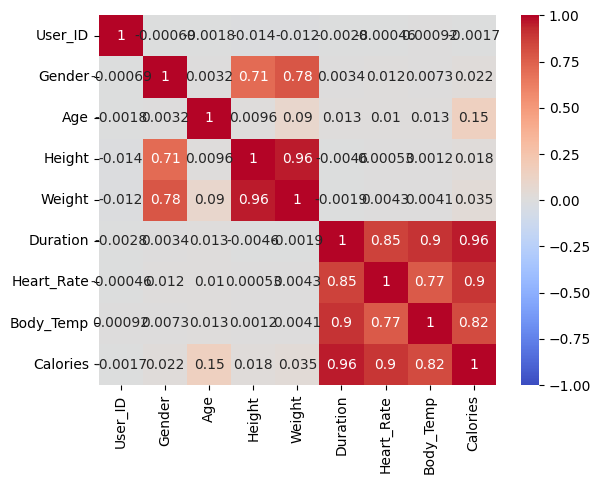

In [9]:
import seaborn as sns

corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

In [10]:
# Convert Dataframe to tensors

X = np.array(X)
y = np.array(y)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

In [11]:
print(X, X.shape)
print(y, y.shape)

tensor([[  1.0000,  68.0000, 190.0000,  ...,  29.0000, 105.0000,  40.8000],
        [  0.0000,  20.0000, 166.0000,  ...,  14.0000,  94.0000,  40.3000],
        [  1.0000,  69.0000, 179.0000,  ...,   5.0000,  88.0000,  38.7000],
        ...,
        [  0.0000,  43.0000, 159.0000,  ...,  16.0000,  90.0000,  40.1000],
        [  1.0000,  78.0000, 193.0000,  ...,   2.0000,  84.0000,  38.3000],
        [  1.0000,  63.0000, 173.0000,  ...,  18.0000,  92.0000,  40.5000]]) torch.Size([15000, 7])
tensor([231.,  66.,  26.,  ...,  75.,  11.,  98.]) torch.Size([15000])


In [12]:
# X = X.unsqueeze(dim=2)
y = y.unsqueeze(dim=1)

print(X, X.shape)
print(y, y.shape)

tensor([[  1.0000,  68.0000, 190.0000,  ...,  29.0000, 105.0000,  40.8000],
        [  0.0000,  20.0000, 166.0000,  ...,  14.0000,  94.0000,  40.3000],
        [  1.0000,  69.0000, 179.0000,  ...,   5.0000,  88.0000,  38.7000],
        ...,
        [  0.0000,  43.0000, 159.0000,  ...,  16.0000,  90.0000,  40.1000],
        [  1.0000,  78.0000, 193.0000,  ...,   2.0000,  84.0000,  38.3000],
        [  1.0000,  63.0000, 173.0000,  ...,  18.0000,  92.0000,  40.5000]]) torch.Size([15000, 7])
tensor([[231.],
        [ 66.],
        [ 26.],
        ...,
        [ 75.],
        [ 11.],
        [ 98.]]) torch.Size([15000, 1])


### Train-Test data splitting

In [13]:
# Splitting data into 80-20 (train-test) blocks

train_split = int(0.8 * len(X))

X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

print(len(X_train), len(y_train))
print(len(X_test), len(y_test))

12000 12000
3000 3000


In [14]:
print(len(X[0]), len(y[0]))

7 1


### Data Visualiation

In [15]:
df

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,1,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,0,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,1,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,0,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,0,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...,...
14995,15644082,0,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,0,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,0,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,1,78,193.0,97.0,2.0,84.0,38.3,11.0


In [16]:
len(X[:,1]), len(y)

(15000, 15000)

In [17]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    """
    Plot training data and testing data onto a scatter plot with predictions
    """

    fig, ax = plt.subplots(nrows=2, ncols=4, layout='constrained', figsize=(10,5))

    # Training data with blue
    ax[0, 0].scatter(X_train[:,0], y_train, c="b", s=4); ax[0, 0].set_title("Gender")
    ax[0, 1].scatter(X_train[:,1], y_train, c="b", s=4); ax[0, 1].set_title("Age")
    ax[0, 2].scatter(X_train[:,2], y_train, c="b", s=4); ax[0, 2].set_title("Height")
    ax[0, 3].scatter(X_train[:,3], y_train, c="b", s=4); ax[0, 3].set_title("Weight")
    ax[1, 0].scatter(X_train[:,4], y_train, c="b", s=4); ax[1, 0].set_title("Duration")
    ax[1, 1].scatter(X_train[:,5], y_train, c="b", s=4); ax[1, 1].set_title("Heart_Rate")
    ax[1, 2].scatter(X_train[:,6], y_train, c="b", s=4); ax[1, 2].set_title("Body_Temp")

    plt.legend(prop={"size" : 14})

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_10800\3742089347.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(prop={"size" : 14})


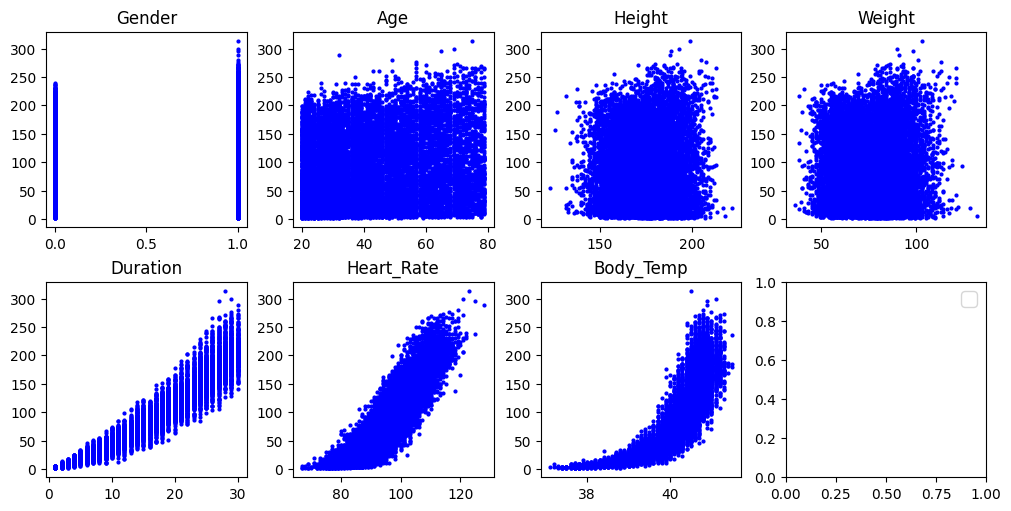

In [18]:
plot_predictions()

### Normalization of features

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Normalizaed training and testing values
X_train_scaled = scaler.fit_transform(X_train)
X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_scaled = scaler.fit_transform(X_test)
X_test = torch.tensor(X_test, dtype=torch.float32)

print(X_train.shape, X_test.shape)

torch.Size([12000, 7]) torch.Size([3000, 7])


C:\Users\VICTUS\AppData\Local\Temp\ipykernel_10800\643452084.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype=torch.float32)


### Put data on GPU for training

In [20]:
torch.cuda.is_available()

True

In [21]:
torch.__version__, torch.version.cuda

('2.12.0+cu126', '12.6')

In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"

X.device, y.device

(device(type='cpu'), device(type='cpu'))

In [23]:
# Put data on to GPU (cuda)
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

In [24]:
print(X_train.device, y_train.device, X_test.device, y_test.device)

cuda:0 cuda:0 cuda:0 cuda:0


## Model Building

To-Do - install pytorch GPU version by this command - `pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126`

In [ ]:
# Create model architecture

class LinearRegressionModel(nn.Module):
    def __init__(self, dropout_rate=0.1):
        super().__init__()

        # Initialize layers
        # Input layer
        self.in_layer = nn.Linear(in_features=7,
                                  out_features=8)
        self.drop1 = nn.Dropout(p=dropout_rate)

        # Hidden layer 1
        self.hidden_1 = nn.Linear(in_features=8,
                                  out_features=4)
        self.drop2 = nn.Dropout(p=dropout_rate)

        # Output layer
        self.out_layer = nn.Linear(in_features=4,
                                   out_features=1)

        # Activation function ReLU
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.in_layer(x))
        x = self.drop1(x)
        x = self.relu(self.hidden_1(x))
        x = self.drop2(x)
        x = self.out_layer(x)
        return x
    
torch.manual_seed(42)

# Instantiate a model
model = LinearRegressionModel()

print(model, model.state_dict())

LinearRegressionModel(
  (in_layer): Linear(in_features=7, out_features=8, bias=True)
  (hidden_1): Linear(in_features=8, out_features=4, bias=True)
  (out_layer): Linear(in_features=4, out_features=1, bias=True)
  (relu): ReLU()
) OrderedDict([('in_layer.weight', tensor([[ 0.2890,  0.3137, -0.0885,  0.3472, -0.0828,  0.0763, -0.1840],
        [ 0.2220,  0.3332, -0.2773,  0.3285,  0.0707,  0.2792,  0.0512],
        [ 0.1822, -0.0534,  0.2914,  0.0559, -0.1764,  0.0963, -0.1741],
        [-0.0443, -0.1535,  0.2507, -0.2984, -0.1742, -0.1067, -0.2273],
        [ 0.0357, -0.3733,  0.3413, -0.3211,  0.2918,  0.0629, -0.1227],
        [ 0.2336,  0.0589,  0.3054,  0.0413, -0.1192,  0.1016, -0.1025],
        [ 0.1591,  0.3375,  0.2185, -0.1652,  0.2182,  0.0676,  0.1919],
        [-0.2304, -0.3742, -0.1460, -0.2899,  0.3101,  0.1089,  0.1566]])), ('in_layer.bias', tensor([ 0.1195, -0.0066,  0.2958, -0.2685,  0.0238, -0.2580,  0.1165, -0.1302])), ('hidden_1.weight', tensor([[ 0.1083, -0.0737, 

## Training

For training we need:
* Loss function
* Optimizer
* Training loop
* Testing loop

In [26]:
# Check the model's current device
next(model.parameters()).device

device(type='cpu')

In [27]:
# Set model device to gpu
model.to(device)
next(model.parameters()).device

device(type='cuda', index=0)

### Loss function and Optimizer

In [28]:
# Loss function (Mean Absolute Error -> MAE)
loss_fn = nn.L1Loss()

# Optimizer
optimizer = torch.optim.SGD(params=model.parameters(),
                         lr=0.01)

### Training and Testing loop

d:\VS Code\Learning\PyTorch\.venv\Lib\site-packages\torch\nn\modules\loss.py:129: UserWarning: Using a target size (torch.Size([12000, 1])) that is different to the input size (torch.Size([12000])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


Epoch : 0 | Loss : 89.78076934814453 | Test-loss : 97.12013244628906
Epoch : 10 | Loss : 89.64508819580078 | Test-loss : 95.81005859375
Epoch : 20 | Loss : 89.51744079589844 | Test-loss : 94.82516479492188
Epoch : 30 | Loss : 89.39571380615234 | Test-loss : 94.0738754272461
Epoch : 40 | Loss : 89.2782974243164 | Test-loss : 93.48748016357422
Epoch : 50 | Loss : 89.16389465332031 | Test-loss : 93.0127182006836
Epoch : 60 | Loss : 89.05148315429688 | Test-loss : 92.60760498046875
Epoch : 70 | Loss : 88.94017028808594 | Test-loss : 92.2369155883789
Epoch : 80 | Loss : 88.82915496826172 | Test-loss : 91.86922454833984
Epoch : 90 | Loss : 88.71769714355469 | Test-loss : 91.47412109375
Epoch : 100 | Loss : 88.60514068603516 | Test-loss : 91.01899719238281
Epoch : 110 | Loss : 88.49072265625 | Test-loss : 90.46720886230469
Epoch : 120 | Loss : 88.37309265136719 | Test-loss : 89.77315521240234
Epoch : 130 | Loss : 88.25093841552734 | Test-loss : 88.88081359863281
Epoch : 140 | Loss : 88.122573

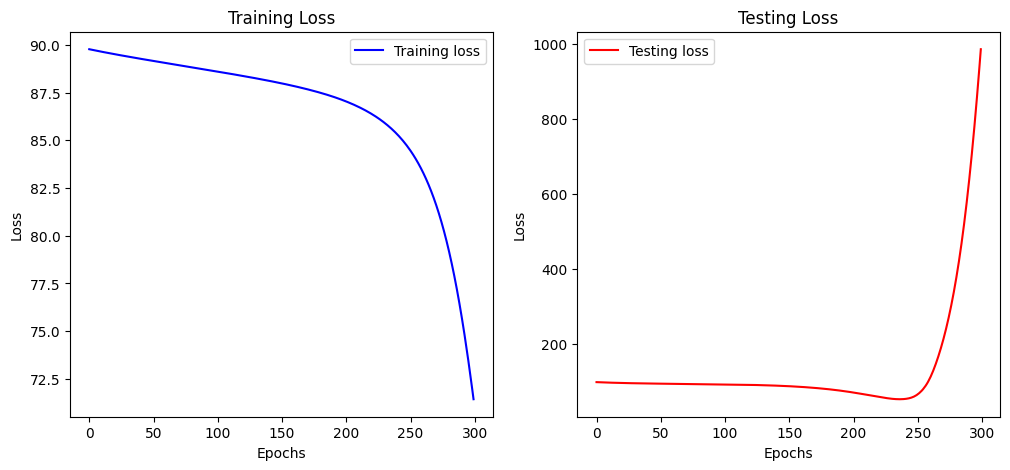

In [29]:
# Training and Testing loop
torch.manual_seed(42)

epochs = 300
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):

    ### Training
    model.train()

    # 1. Froward pass
    y_preds = model(X_train)
    y_preds = y_preds.squeeze()

    # 2. Calculate loss
    loss = loss_fn(y_preds, y_train)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Perform backpropagation
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model.eval()
    with torch.inference_mode():
        test_preds = model(X_test)
        test_loss = loss_fn(test_preds, y_test)

    # Store metrics
    epoch_count.append(epoch)
    train_loss_values.append(loss.item())
    test_loss_values.append(test_loss.item())

    # Print metrics during training
    if epoch % 10 == 0:
        print(f"Epoch : {epoch} | Loss : {loss} | Test-loss : {test_loss}")
    
# Plot Training losses
ax[0].plot(epoch_count, train_loss_values, c="b", label="Training loss")
ax[0].set_title("Training Loss")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss")
ax[0].legend()

# Plot Testing losses
ax[1].plot(epoch_count, test_loss_values, c="r", label="Testing loss")
ax[1].set_title("Testing Loss")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")
ax[1].legend()

plt.show()

In [30]:
loss.item(), epoch

(71.42596435546875, 299)

Hmm...
<br>
Issue - Model's learning rate is very slow. 
<br>
Solutions -
* Increase the learning rate
* Normalize the dataset features

-> Fixed

Ok now some imporvement. Now the model is getting overfit. So i'll add neuron dropout